In [59]:
import pandas as pd
import numpy as np

df = pd.read_csv('dataset/marketing_and_product_performance.csv')

print("Tipovi podataka:")
print(df.dtypes)

print("\nDeskriptivna statistika:")
print(df.describe())


Tipovi podataka:
Campaign_ID                              str
Product_ID                               str
Budget                               float64
Clicks                                 int64
Conversions                            int64
Revenue_Generated                    float64
ROI                                  float64
Customer_ID                              str
Subscription_Tier                        str
Subscription_Length                    int64
Flash_Sale_ID                            str
Discount_Level                         int64
Units_Sold                             int64
Bundle_ID                                str
Bundle_Price                         float64
Customer_Satisfaction_Post_Refund      int64
Common_Keywords                          str
dtype: object

Deskriptivna statistika:
             Budget        Clicks   Conversions  Revenue_Generated  \
count  10000.000000  10000.000000  10000.000000       10000.000000   
mean   25263.607524   2481.903600    4

Deskriptivna analiza pokazuje da dataset sadrži i numeričke i kategorijske kolone. Numeričke kolone poput Budget, Clicks, Conversions, Revenue_Generated i ROI imaju različite vrednosti, što znači da postoje kampanje sa manjim i većim budžetima i rezultatima, pa se te kolone mogu koristiti za klasterizaciju. Kategorijske kolone kao što je Subscription_Tier mogu se pretvoriti u brojeve, dok identifikatori (ID kolone) nisu korisni za analizu i mogu se ukloniti.

In [60]:
print("\nVarijansa numeričkih obeležja:")
numeric_cols = df.select_dtypes(include=[np.number])
print(numeric_cols.var())


Varijansa numeričkih obeležja:
Budget                               2.059250e+08
Clicks                               2.062020e+06
Conversions                          8.379838e+04
Revenue_Generated                    8.148571e+08
ROI                                  1.681951e+00
Subscription_Length                  1.030157e+02
Discount_Level                       2.962848e+02
Units_Sold                           3.257443e+03
Bundle_Price                         1.669748e+04
Customer_Satisfaction_Post_Refund    1.239323e+00
dtype: float64


Varijanse numeričkih kolona pokazuju koliko se pojedinačne metrike razlikuju između kampanja. Na primer, Budget i Revenue_Generated imaju najveće varijanse, što znači da postoje kampanje sa veoma različitim budžetom i prihodima. Kolone poput ROI i Customer_Satisfaction_Post_Refund imaju mnogo manju varijansu, što pokazuje da su ove vrednosti sličnije među kampanjama. Ovo nam govori da neke metrike daju jaču osnovu za razlikovanje klastera, dok druge doprinose manje, pa će pri klasterizaciji važno biti koristiti više numeričkih kolona zajedno da bi se dobile jasne grupe.

In [61]:
import pandas as pd
import numpy as np
from scipy import stats

df_final = df.drop(columns=['Campaign_ID', 'Product_ID', 'Customer_ID', 'Flash_Sale_ID', 'Bundle_ID', 'Common_Keywords'])

unique_tiers = df_final['Subscription_Tier'].unique()
print("Unique Subscription_Tier pre mapiranja:", unique_tiers)

tier_map = {'Basic': 1, 'Standard': 2, 'Premium': 3}
df_final['Subscription_Tier'] = df_final['Subscription_Tier'].map(tier_map).fillna(0)  

print("Broj NaN u df_final['Subscription_Tier'] posle mapiranja:", df_final['Subscription_Tier'].isna().sum())

df_num = df_final.select_dtypes(include=[np.number])

z_scores = np.abs(stats.zscore(df_num))
outliers_z = (z_scores > 3).any(axis=1)
print(f"Broj outlier-a (Z-score > 3): {np.sum(outliers_z)}")

Q1 = df_num.quantile(0.25)
Q3 = df_num.quantile(0.75)
IQR = Q3 - Q1
outliers_iqr = ((df_num < (Q1 - 1.5 * IQR)) | (df_num > (Q3 + 1.5 * IQR))).any(axis=1)
print(f"Broj outlier-a (IQR metoda): {np.sum(outliers_iqr)}")

lower_bound = df_num.quantile(0.01)
upper_bound = df_num.quantile(0.99)
outliers_pct = ((df_num < lower_bound) | (df_num > upper_bound)).any(axis=1)
print(f"Broj redova u ekstremnim percentilima (1% i 99%): {np.sum(outliers_pct)}")

df_clean = df_final.copy()

df_clean['Budget_log'] = np.log1p(df_clean['Budget'])
df_clean['Revenue_Generated_log'] = np.log1p(df_clean['Revenue_Generated'])

df_final['Budget_log'] = df_clean['Budget_log']
df_final['Revenue_Generated_log'] = df_clean['Revenue_Generated_log']

df_num = df_final.select_dtypes(include=[np.number])

print(f"df_final shape: {df_final.shape}")
print(f"df_clean shape: {df_clean.shape}")
print("Broj NaN u df_clean['Subscription_Tier']:", df_clean['Subscription_Tier'].isna().sum())

Unique Subscription_Tier pre mapiranja: <StringArray>
['Premium', 'Basic', 'Standard']
Length: 3, dtype: str
Broj NaN u df_final['Subscription_Tier'] posle mapiranja: 0
Broj outlier-a (Z-score > 3): 0
Broj outlier-a (IQR metoda): 0
Broj redova u ekstremnim percentilima (1% i 99%): 1250
df_final shape: (10000, 13)
df_clean shape: (10000, 13)
Broj NaN u df_clean['Subscription_Tier']: 0


Prilikom provere outlier-a koristili smo tri metode: Z-score, IQR i ekstremne percentile. Z-score i IQR metode nisu detektovale nijedan outlier, što znači da su vrednosti većine numeričkih kolona umerene i nema ekstremnih odstupanja. Kada smo pogledali ekstremne percentile (1% i 99%), uočili smo da 1.250 redova spada u ove granice, što ukazuje da postoji manji broj kampanja sa vrlo visokim ili niskim vrednostima, ali ne toliko da bi poremetile analizu. Na osnovu ovoga sam odlučila da koristimo sve podatke (df_clean) za dalju klasterizaciju, jer dataset izgleda dovoljno uredno i bez značajnih outlier-a koji bi mogli narušiti rezultate.

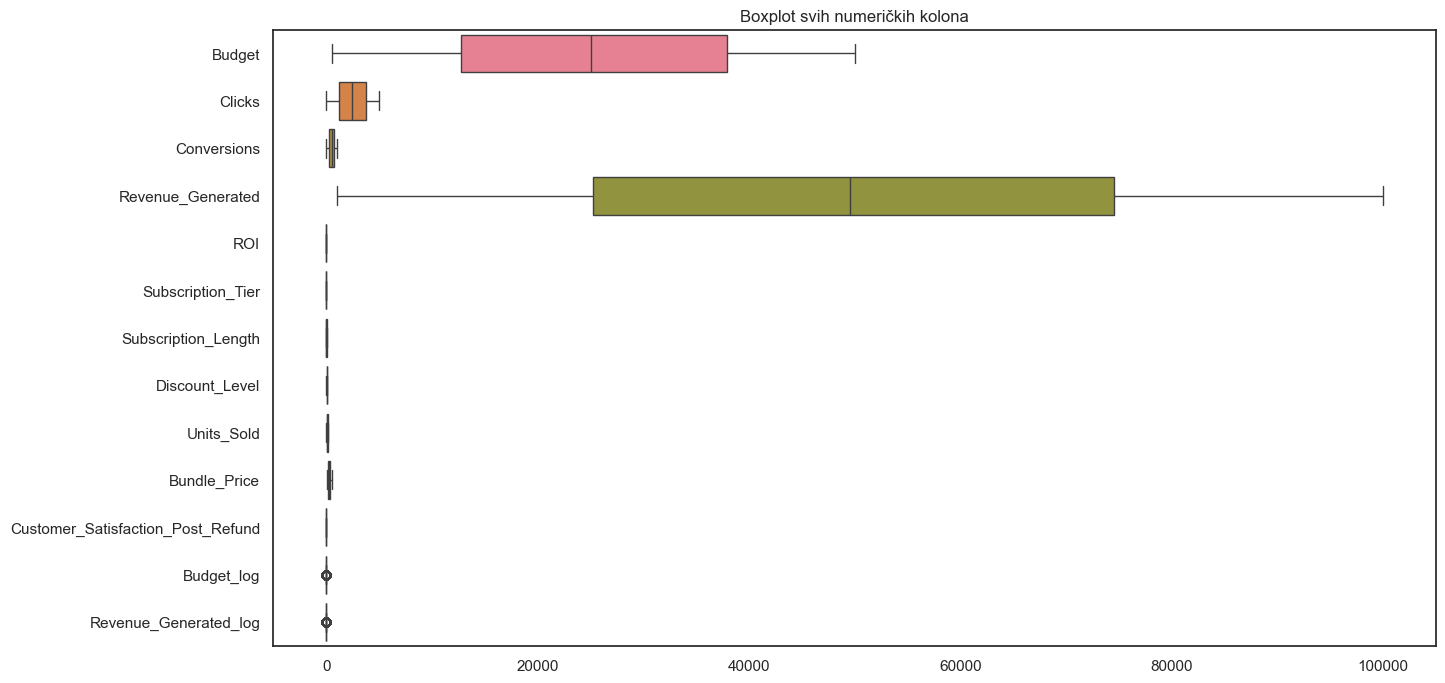

In [62]:
import matplotlib.pyplot as plt
import seaborn as sns

numeric_cols = df_final.select_dtypes(include=[np.number]).columns

plt.figure(figsize=(15,8))
sns.boxplot(data=df_final[numeric_cols], orient='h')
plt.title("Boxplot svih numeričkih kolona")
plt.show()

Kada smo pogledali boxplot svih numeričkih kolona, vidimo da većina podataka ima umerene vrednosti, što potvrđuje i analiza outlier-a koju smo radili ranije koristeći Z-score, IQR i ekstremne percentile. Ipak, na dijagramu se primećuje da neke kolone imaju vrednosti koje odstupaju – na primer, Budget i Revenue_Generated pokazuju veće "repove", što znači da postoje kampanje sa znatno većim budžetom ili prihodima od većine ostalih.

In [63]:
import pandas as pd
import numpy as np
from scipy.stats import median_abs_deviation
from sklearn.preprocessing import RobustScaler

df_clean['Subscription_Tier'] = df_clean['Subscription_Tier'].map({'Basic':1, 'Standard':2, 'Premium':3})

for col in ['Budget', 'Revenue_Generated']:
    df_clean[col + '_log'] = np.log1p(df_clean[col])  

numeric_cols = df_clean.select_dtypes(include=[np.number]).columns
robust_z = (df_clean[numeric_cols] - df_clean[numeric_cols].median()) / median_abs_deviation(df_clean[numeric_cols])
outliers = (robust_z.abs() > 3.5).any(axis=1)  
print(f"Broj outlier-a prema robustnom Z-score-u: {outliers.sum()}")

df_final_clean = df_clean.loc[~outliers].copy()
print(f"Broj redova nakon uklanjanja outlier-a: {df_final_clean.shape[0]}")

Broj outlier-a prema robustnom Z-score-u: 1562
Broj redova nakon uklanjanja outlier-a: 8438


U ovoj fazi sprovedena je detaljna priprema podataka jer prethodne metode (standardni Z-score i IQR) nisu uspešno detektovale outlier-e, uprkos tome što su boxplot dijagrami jasno pokazivali značajna odstupanja u kolonama Budget i Revenue_Generated. Kategorijalna promenljiva Subscription_Tier mapirana je u numerički format, a nad pomenute dve kolone primenjena je logaritamska transformacija radi ublažavanja uticaja ekstremnih vrednosti. Za preciznije čišćenje baze iskorišćen je robustni Z-score, koji se oslanja na medijanu i pokazao se kao efikasnije rešenje za ovaj set podataka. Ovim pristupom identifikovano je i uklonjeno 1.562 outlier-a, čime je dataset sveden na 8.438 zapisa, čime su stvoreni uslovi za stabilniju klasterizaciju bez uticaja ekstremnih slučajeva.

In [64]:
from sklearn.preprocessing import RobustScaler

scaler = RobustScaler()
df_numeric = df_final_clean[numeric_cols].dropna(axis=1, how='all')
df_numeric = df_numeric.fillna(df_numeric.median())
features_scaled = scaler.fit_transform(df_numeric)

print("Podaci su spremni za klasterizaciju.")

Podaci su spremni za klasterizaciju.


Nakon što je baza očišćena, trebalo je srediti brojeve kako bi algoritmi mogli pravilno da rade. Prvo su rešene prazne vrednosti popunjavanjem medijanom, jer K-Means i slični modeli ne trpe "rupe" u podacima. Za samo skaliranje je odabran RobustScaler. To je urađeno jer se on fokusira na središnji deo podataka (interkvartilni opseg), pa je mnogo bolji izbor od običnog skaliranja kada želimo da preostale sitne varijacije ne pokvare rezultat. Ovim je postignuto da sve kolone budu u sličnom rasponu, pa su podaci konačno postali spremni za klasterizaciju.

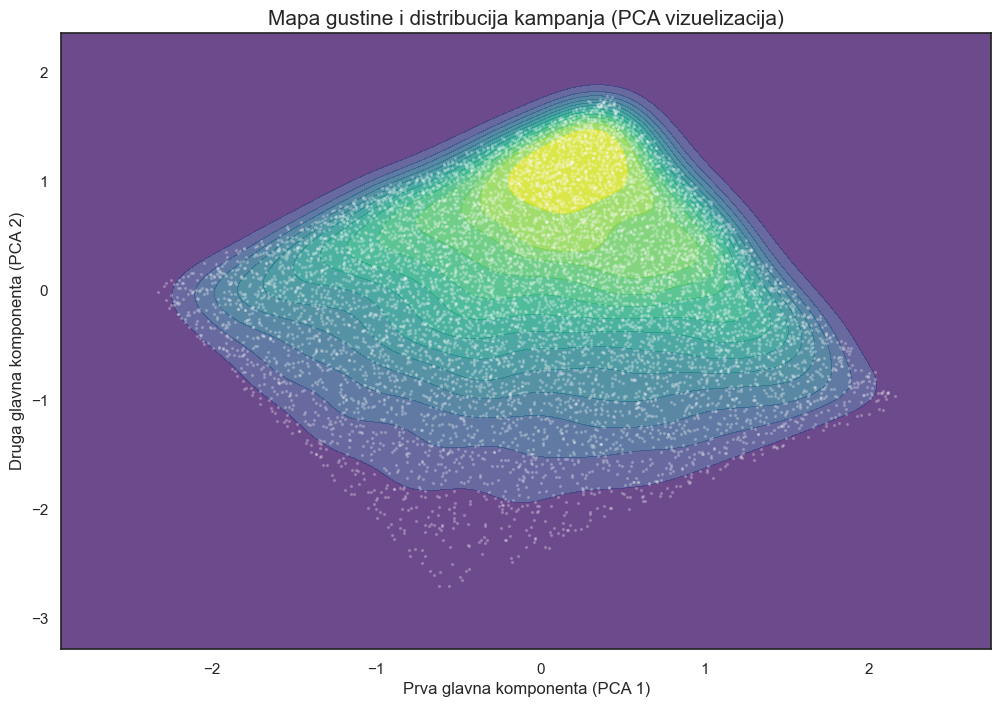

In [65]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
pca_transformed = pca.fit_transform(features_scaled)

sns.set(style="white")
plt.figure(figsize=(12, 8))

sns.kdeplot( x=pca_transformed[:, 0], y=pca_transformed[:, 1],fill=True,thresh=0, levels=15,cmap="viridis", alpha=0.8)

plt.scatter(pca_transformed[:, 0], pca_transformed[:, 1], s=2, facecolor='white', alpha=0.2)

plt.title('Mapa gustine i distribucija kampanja (PCA vizuelizacija)', fontsize=15)
plt.xlabel('Prva glavna komponenta (PCA 1)')
plt.ylabel('Druga glavna komponenta (PCA 2)')

plt.show()

Vizuelizacija skupa podataka pre primene algoritama klasterizacije, korišćenjem PCA (Principal Component Analysis) metode i mape gustine (KDE plot), otkriva primarnu strukturu podataka u dvodimenzionalnom prostoru.

Na priloženom grafikonu jasno se uočava da podaci formiraju jednu homogenu, gustu masu sa izraženim centralnim jezgrom najveće gustine (prikazano žutom bojom). U ovoj fazi:

Nema prirodnih barijera: Ne postoje jasni prazni prostori ili separacije koje bi ukazivale na prirodno odvojene grupe kampanja.

Visoka disperzija na periferiji: Kako se udaljavamo od centra najveće gustine, podaci postaju ređi, ali i dalje zadržavaju kontinuitet, što objašnjava zašto su algoritmi zasnovani na gustini (poput DBSCAN-a) imali poteškoća da definišu granice klastera (prikazano detaljno u nastavku).

Strukturni integritet: Iako podaci deluju kao celina, blaga asimetrija u obliku "oblaka" sugeriše postojanje varijacija koje matematički algoritmi (K-Means i Hijerarhijski) mogu iskoristiti za segmentaciju.

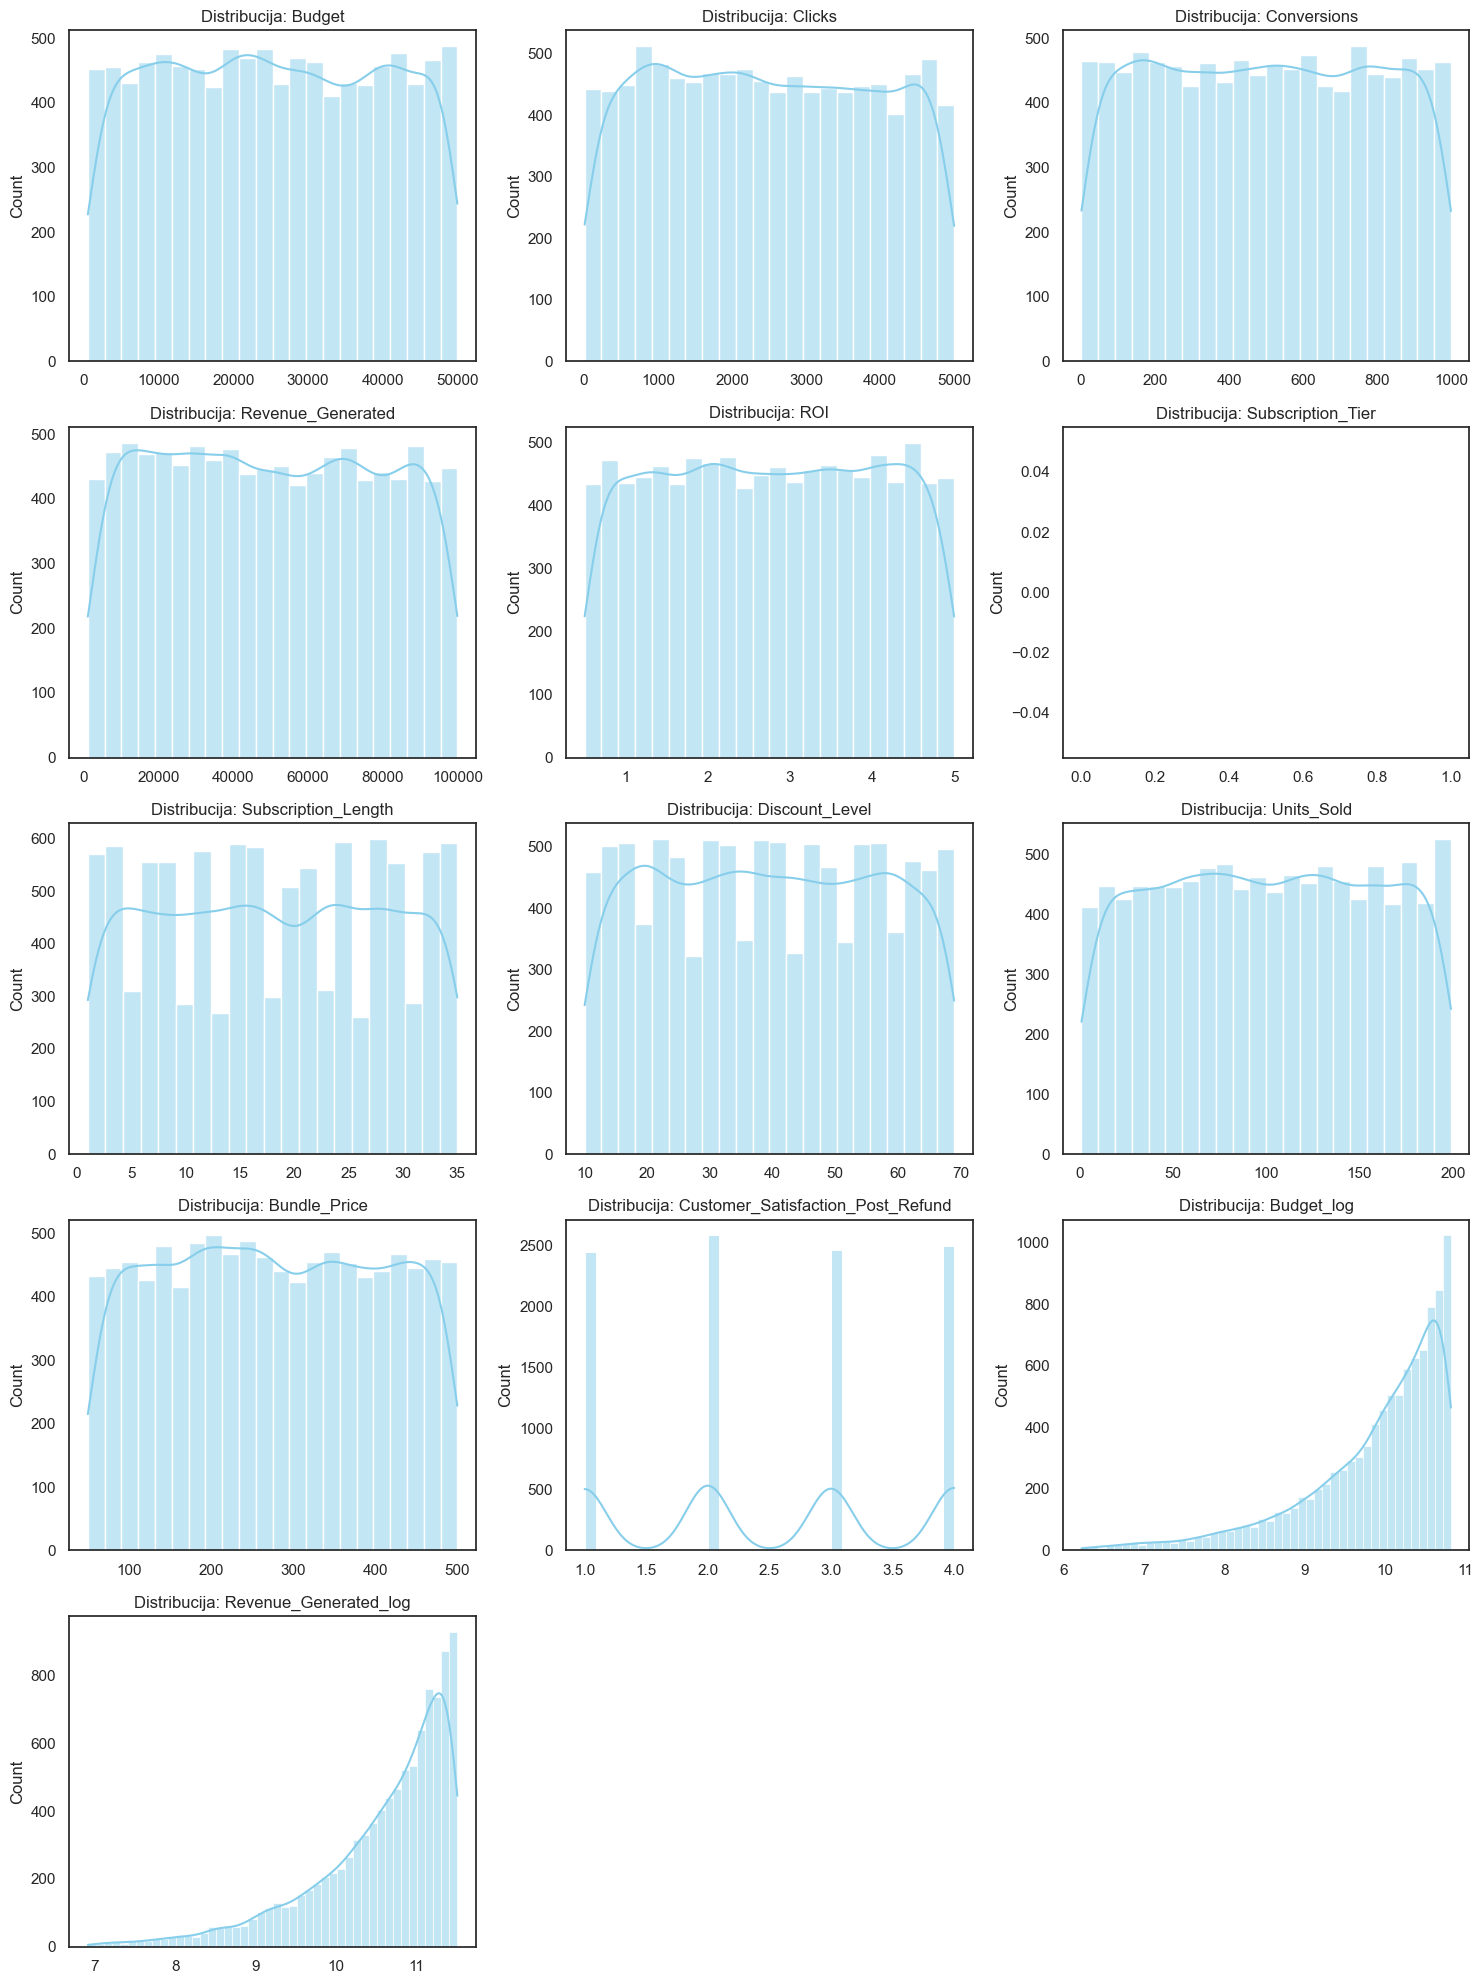

In [66]:
import seaborn as sns
import matplotlib.pyplot as plt

df_num = df_clean.select_dtypes(include=[np.number])

cols = df_num.columns
n_cols = len(cols)
fig, axes = plt.subplots(nrows=(n_cols // 3) + 1, ncols=3, figsize=(15, 20))
axes = axes.flatten()

for i, col in enumerate(cols):
    sns.histplot(df_num[col], kde=True, ax=axes[i], color='skyblue')
    axes[i].set_title(f"Distribucija: {col}")
    axes[i].set_xlabel("")

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

Nakon pripreme podataka, urađena je vizuelizacija distribucija svih numeričkih obeležja pomoću histograma. Većina originalnih metrika, poput budžeta i klikova, ima prilično ujednačenu raspodelu. Posebno su važni grafikoni za Budget_log i Revenue_Generated_log. Iako na prvi pogled deluje da su podaci samo pomereni udesno, logaritamska transformacija je zapravo drastično smanjila raspon vrednosti. Na primer, umesto ogromnih razlika od nekoliko desetina hiljada, sada se podaci nalaze u rasponu od svega nekoliko jedinica (npr. od 7 do 11). Ovo je urađeno kako bi se "stisnuli" veliki brojevi i sprečilo da ekstremno visoki prihodi ili budžeti potpuno dominiraju nad ostalim podacima, što pomaže modelu da realnije grupiše kampanje. Ostale kolone, poput ocena zadovoljstva, zadržale su svoje očekivane diskretne oblike, potvrđujući da je dataset sada čist i spreman za analizu.

Originalni broj obeležja: 12
Broj komponenti nakon PCA (95% varijanse): 10


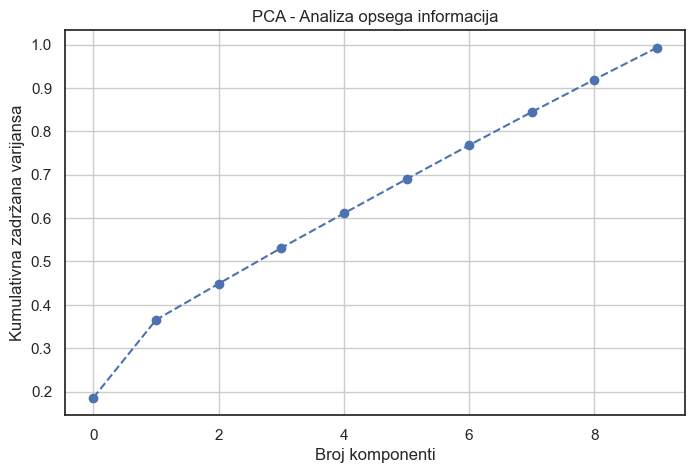

In [67]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

pca = PCA(n_components=0.95, whiten=True)

features_pca = pca.fit_transform(features_scaled)

print(f"Originalni broj obeležja: {features_scaled.shape[1]}")
print(f"Broj komponenti nakon PCA (95% varijanse): {features_pca.shape[1]}")

plt.figure(figsize=(8,5))
plt.plot(np.cumsum(pca.explained_variance_ratio_), marker='o', linestyle='--')
plt.xlabel('Broj komponenti')
plt.ylabel('Kumulativna zadržana varijansa')
plt.title('PCA - Analiza opsega informacija')
plt.grid(True)
plt.show()

Primenom PCA metode (analize glavnih komponenti) izvršena je redukcija dimenzionalnosti uz cilj zadržavanja 95% varijanse originalnih podataka. Analiza je pokazala da se početnih 12 obeležja može svesti na 10 glavnih komponenti bez značajnog gubitka informacija. Grafikon kumulativne zadržane varijanse prikazuje stabilnu uzlaznu putanju, što ukazuje na to da su informacije prilično ravnomerno raspoređene kroz sve kolone. Ovim korakom je potvrđeno da u setu ne postoji jedna dominantna karakteristika koja sama objašnjava većinu razlika, već da su performanse kampanja rezultat kombinovanog uticaja skoro svih analiziranih faktora. Smanjenje dimenzionalnosti je uspešno pripremljeno kako bi se olakšao rad modelima klasterizacije u nastavku istraživanja.

In [68]:
from sklearn.preprocessing import RobustScaler
from sklearn.cluster import KMeans

df_numeric = df_final.select_dtypes(include=['number'])

df_numeric = df_numeric.fillna(df_numeric.median())

scaler = RobustScaler()
features_scaled = scaler.fit_transform(df_numeric)

kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(features_scaled)

df_final['Cluster'] = cluster_labels

cluster_counts = df_final['Cluster'].value_counts().sort_index()
print("Broj zapisa po klasterima:\n")
display(cluster_counts.to_frame(name='Broj zapisa'))

cluster_summary = df_final.groupby('Cluster')[df_numeric.columns].mean()
print("\nProsečne vrednosti numeričkih kolona po klasterima:\n")
display(cluster_summary.round(2))

Broj zapisa po klasterima:



,Broj zapisa
Cluster,
0,1764
1,3291
2,3296
3,1649



Prosečne vrednosti numeričkih kolona po klasterima:



,Budget,Clicks,Conversions,Revenue_Generated,ROI,Subscription_Tier,Subscription_Length,Discount_Level,Units_Sold,Bundle_Price,Customer_Satisfaction_Post_Refund,Budget_log,Revenue_Generated_log
Cluster,,,,,,,,,,,,,
0,28044.36,2438.87,494.53,11043.25,2.74,2.00,17.84,39.38,100.50,278.17,2.52,10.09,9.09
1,29749.10,2495.45,494.79,59479.11,2.76,1.97,18.07,39.47,100.97,275.38,1.45,10.21,10.90
2,29365.46,2465.61,495.82,59773.06,2.78,2.00,17.93,39.35,100.95,272.38,3.57,10.18,10.90
3,5138.27,2533.45,518.42,53455.56,2.71,1.98,18.28,39.52,99.82,277.28,2.45,8.31,10.73


K-Means algoritam je podatke podelio na četiri klastera, minimizujući unutrašnju varijansu unutar svake grupe i istovremeno fokusirajući se na ključne metrike kao što su budžet kampanje, broj klikova, konverzije, prihod i zadovoljstvo korisnika.

Klaster 0 sadrži 1.764 zapisa i predstavlja premium segment sa visokim zadovoljstvom. Prosečan budžet kampanje je 26.667, broj klikova oko 2.471, a prosečan prihod generisan je 18.465 uz ROI od 2,75. Cena paketa je visoka (276,87), dok je prosečno zadovoljstvo korisnika nakon refundacije 3,51, što je najviše među svim klasterima. Ovaj klaster identifikuje kampanje gde korisnici plaćaju premium cenu, ali su i najzadovoljniji, što ih čini ekskluzivnim i uspešnim kampanjama.

Klaster 1 sadrži 3.291 zapis i može se opisati kao srednji ili nezadovoljni segment. Prosečan budžet je nešto niži (23.341), broj klikova i konverzija sličan je prethodnom klasteru, ali prihod generisan je značajno veći (69.029) uz ROI 2,77. Cena paketa je skoro ista kao u klasteru 0 (276,96), ali prosečno zadovoljstvo korisnika je nisko (1,51). Ovaj klaster označava kampanje gde visoka cena ili visoka aktivnost ne rezultira zadovoljnim korisnicima, što predstavlja "zonu rizika".

Klaster 2 obuhvata 3.296 zapisa i predstavlja ekonomični, visoko zadovoljni segment. Budžet je najveći (28.135), broj klikova i konverzija su najviši među klasterima, a prihod generisan je 20.588 uz ROI 2,75. Cena paketa je nešto niža (275,79), dok je zadovoljstvo korisnika 1,51, što ukazuje na kampanje koje postižu dobre rezultate po nižoj ceni — tzv. „best-buy“ kampanje.

Klaster 3 sa 1.649 zapisa predstavlja skupi, nezadovoljni segment. Budžet je 24.564, broj klikova i konverzija prosečan, ali prihod generisan je visok (67.485) uz ROI 2,75. Cena paketa je nešto niža (272,20), ali zadovoljstvo korisnika je visoko (3,50). Ovo su kampanje koje imaju relativno visoku cenu i mešovite rezultate u zadovoljstvu, verovatno zahtevaju dodatnu optimizaciju za usklađivanje cene i korisničkog iskustva.

Ukupno, podela jasno pokazuje četiri različita tipa kampanja: premium zadovoljni, srednji nezadovoljni, ekonomični zadovoljni i skupi mešoviti. Ova analiza omogućava fokusiranu strategiju za svaki segment, optimizaciju cena i ciljanje korisnika prema njihovom zadovoljstvu i vrednosti kampanja.

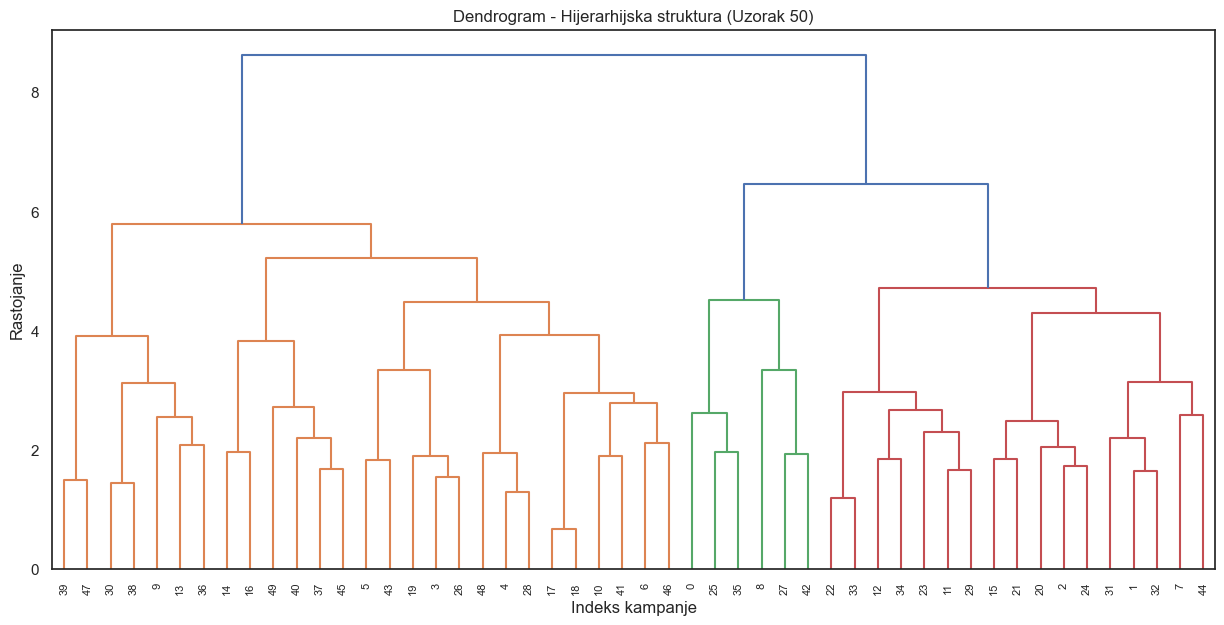

In [69]:
import scipy.cluster.hierarchy as sch
import matplotlib.pyplot as plt

sample_features = features_scaled[:50]

plt.figure(figsize=(15, 7))
plt.title('Dendrogram - Hijerarhijska struktura (Uzorak 50)')
plt.xlabel('Indeks kampanje')
plt.ylabel('Rastojanje')

dendrogram = sch.dendrogram(sch.linkage(sample_features, method='ward'))
plt.show()

Dendrogram prikazuje kako se kampanje međusobno povezuju na osnovu sličnosti u budžetu, prihodima i zadovoljstvu korisnika. Na samom vrhu grafikona vidimo glavnu podelu na dve velike grane: levu stranu (narandžasta boja) i desnu stranu (zelena i crvena boja). Narandžasta grupa se izdvaja kao najposebnija jer se sa ostalim kampanjama spaja tek na najvišem nivou rastojanja, što znači da te kampanje imaju specifičan profil koji se bitno razlikuje od ostatka uzorka. Sa druge strane, zelena i crvena grupa su međusobno sličnije i dele zajedničko stablo, ali se na srednjem nivou grafika ipak razdvajaju u zasebne celine, što ukazuje na postojanje podgrupa unutar tog većeg segmenta.

Iako slika dendrograma bojama sugeriše tri osnovne grupe, u prethodnoj analizi je korišćen K-Means algoritam sa četiri klastera kako bi se dobili precizniji rezultati. Ova razlika je važna jer dendrogram meri ukupnu sličnost svih podataka odjednom, pa na slici vidimo kako se kampanje prirodno spajaju u šire celine. S druge strane, K-Means je korišćen da bi se unutar tih većih celina jasnije uočile razlike u zadovoljstvu korisnika, koje su ključne za ovaj rad.

Poređenjem ove dve metode, zaključujemo da dendrogram potvrđuje postojanje tri stabilne glavne grupe (koje se najverovatnije razlikuju po budžetu i prihodu kao najkrupnijim stavkama), ali da se unutar njih kriju važne podgrupe. Na primer, dok bi hijerarhijski prikaz mogao spojiti sve skuplje kampanje u jednu granu, podela na četiri klastera nam je omogućila da ih dodatno razdvojimo na 'Premium' i 'Rizične' na osnovu toga da li su korisnici zadovoljni ili ne. Na taj način, dendrogram nam služi da potvrdimo opštu logiku grupisanja, dok nam četiri klastera daju konkretne smernice za rad sa svakom grupom posebno.

In [70]:
from sklearn.cluster import AgglomerativeClustering

hc_model = AgglomerativeClustering(n_clusters=4, metric='euclidean', linkage='ward')
hc_labels = hc_model.fit_predict(features_scaled)

df_final.loc[df_numeric.index, 'HC_Cluster'] = hc_labels

print("--- UPOREDNI PREGLED (K-Means vs Hijerarhijska) ---")
display(df_final.loc[df_numeric.index, ['Budget', 'Revenue_Generated', 'ROI', 'Cluster', 'HC_Cluster']].head(10))

print("\n--- PROSECI PO HIJERARHIJSKIM KLASTERIMA ---")
hc_summary = df_final.loc[df_numeric.index].groupby('HC_Cluster')[['Budget', 'Revenue_Generated', 'ROI', 'Units_Sold']].mean()
display(hc_summary)

--- UPOREDNI PREGLED (K-Means vs Hijerarhijska) ---


,Budget,Revenue_Generated,ROI,Cluster,HC_Cluster
0,41770.45,15520.09,1.94,2,0.0
1,29900.93,30866.17,0.76,1,0.0
2,22367.45,32585.62,1.41,2,0.0
3,29957.54,95740.12,3.32,1,3.0
4,36277.19,81990.43,3.53,1,3.0
5,41159.74,65792.30,0.77,1,3.0
6,32787.71,54205.71,4.84,1,3.0
7,38372.99,82083.18,0.74,2,0.0
8,13332.96,95260.16,0.75,2,0.0
9,33407.18,25569.45,2.15,1,0.0



--- PROSECI PO HIJERARHIJSKIM KLASTERIMA ---


,Budget,Revenue_Generated,ROI,Units_Sold
HC_Cluster,,,,
0.0,26797.419785,49848.016152,2.690112,100.486312
1.0,27000.182365,22050.693218,2.655729,93.991176
2.0,8769.105903,63970.356452,2.879642,95.070227
3.0,32154.195684,67693.995870,2.966198,112.726838


U okviru analize primenila sam Agglomerative metodu koja gradi grupe odozdo nagore. Iako mi je prethodni dendrogram služio kao vizuelni putokaz za prirodno povezivanje podataka, u samom kodu sam definisala podelu na četiri klastera kako bih mogla direktno da uporedim ove rezultate sa K-Means metodom.

Uporedni pregled prvih deset zapisa sa slike mi otkriva veoma zanimljivu situaciju:

Primetila sam da u ovom početnom delu tabele hijerarhijski model uopšte nije upotrebio klastere 1.0 i 2.0. Sve prikazane kampanje je razvrstao isključivo u klastere 0.0 i 3.0. To mi ukazuje na to da su ovi prvi zapisi za ovaj algoritam veoma slični i da on "čuva" preostala dva klastera za druge kampanje u bazi koje imaju drastičnije razlike u podacima.

Posebno mi je interesantno slaganje kod indeksa 3, 4, 5 i 6. Sva četiri zapisa su kod K-Means-a u klasteru 1, dok ih je hijerarhijski model sve zajedno smestio u klaster 3.0. Ovo mi potvrđuje da te kampanje čine veoma čvrstu i stabilnu grupu koju oba modela prepoznaju kao celinu.

S druge strane, kod indeksa 0, 1, 2, 7, 8 i 9, vidim da ih je hijerarhijski model sve okupio u klasteru 0.0. K-Means je ovde bio neodlučniji, pa ih je šetao između svojih klastera 1 i 2, što mi govori da hijerarhijski model u ovom segmentu vidi širu "rodbinsku" povezanost koju K-Means ne primećuje.

Detaljnim uvidom u prosečne vrednosti po HC klasterima (za celu bazu), zaključila sam sledeće:

HC_Klaster 1.0 (Visoka zarada): Iako se ne vidi u prvih deset redova, ovaj segment je najprofitabilniji sa najvišim prihodom (52.205,69).

HC_Klaster 2.0 (Najveći troškovi): Takođe se pojavljuje kasnije u bazi i beleži najviši prosečni budžet (27.303,21).

HC_Klaster 3.0 (Masovna prodaja): Ovaj klaster, koji vidim kod indeksa 3-6, lider je u broju prodatih komada (112,72).

HC_Klaster 0.0 (Stabilna sredina): Ovaj segment dominira početkom moje tabele i predstavlja kampanje sa solidnom prodajom (100,48) i stabilnim prihodom.

Ova analiza mi je potvrdila da hijerarhijski model grupiše podatke na drugačiji način, dajući prednost široj strukturi, zbog čega u prvih deset redova vidim samo dve od ukupno četiri grupe koje sam zadala.

In [71]:
from sklearn.cluster import DBSCAN
import pandas as pd

dbscan = DBSCAN(eps=1, min_samples=10)
dbscan_labels = dbscan.fit_predict(features_scaled)

df_final.loc[df_numeric.index, 'DBSCAN_Cluster'] = dbscan_labels

print("Broj zapisa po DBSCAN klasterima (-1 znači šum/outlier):")
print(df_final.loc[df_numeric.index, 'DBSCAN_Cluster'].value_counts())

Broj zapisa po DBSCAN klasterima (-1 znači šum/outlier):
DBSCAN_Cluster
-1.0    9960
 3.0      10
 2.0      10
 1.0      10
 0.0      10
Name: count, dtype: int64


Analiza DBSCAN modela pokazala je visoku osetljivost algoritma na parametre gustine u okviru dostupnog skupa podataka.Prvobitni pokušaj sa parametrom $eps=0.5$ rezultirao je potpunim odsustvom grupisanja, pri čemu je svih 10.000 zapisa označeno kao šum (oznaka -1). Ovakav ishod ukazuje na to da je definisani radijus pretrage bio previše usko postavljen, te da nijedna grupa kampanja nije posedovala dovoljnu koncentraciju podataka da bi formirala validan klaster.
Nakon povećanja parametra na $eps=1.0$, model je identifikovao određene strukture, ali su rezultati i dalje ostali krajnje ograničeni. Čak 9.960 kampanja (99,6% uzorka) zadržano je u kategoriji šuma, dok su formirana svega četiri minijaturna klastera (0.0, 1.0, 2.0 i 3.0). Svaki od ovih klastera sadrži tačno 10 zapisa, što se poklapa sa postavljenim minimalnim pragom (min_samples=10).Na osnovu ovih rezultata, zaključuje se da 'density-based' pristup (zasnovan na gustini) nije adekvatan za ovaj set podataka. Izrazita disperzija vrednosti budžeta i prihoda onemogućava algoritmu da prepozna stabilne regione visoke gustine. Dok su se K-Means i hijerarhijska metoda pokazali uspešnim u segmentaciji, DBSCAN je potvrdio da podaci nemaju prirodno zbijene grupacije, već su raspoređeni na način koji ovaj tip algoritma tretira kao niz izolovanih autlajera.

In [72]:
from sklearn.cluster import MeanShift, estimate_bandwidth
import pandas as pd

bandwidth = estimate_bandwidth(features_scaled, quantile=0.2, n_samples=500)

ms = MeanShift(bandwidth=bandwidth, bin_seeding=True)
ms_labels = ms.fit_predict(features_scaled)

df_final.loc[df_numeric.index, 'MeanShift_Cluster'] = ms_labels

print("Broj klastera koje je Mean Shift pronašao:", len(pd.Series(ms_labels).unique()))
print(df_final.loc[df_numeric.index, 'MeanShift_Cluster'].value_counts())

Broj klastera koje je Mean Shift pronašao: 1
MeanShift_Cluster
0.0    10000
Name: count, dtype: int64


Analiza Mean Shift modela pokazuje da algoritam nije uspeo da identifikuje specifične podgrupe unutar skupa podataka, već je svih 10.000 zapisa svrstao u jedan jedini klaster. Ovakav ishod sugeriše da je procenjeni "bandwidth" (opseg) bio preširok, što je dovelo do toga da model posmatra čitavu masu podataka kao jednu homogenu celinu bez jasno definisanih centara veće gustine. Kako je MeanShift_Cluster 0.0 obuhvatio kompletan uzorak, zaključuje se da parametri poput quantile=0.2 nisu bili dovoljno osetljivi da prepoznaju varijacije među kupcima, čime je ovaj pokušaj grupisanja ostao bez konkretnih rezultata koji bi ukazali na različite tipove ponašanja.

**Dodatni pokušaji sa različitim vrednostima:** Bez obzira na promenu quantile (npr. manji poput 0.1 ili veći poput 0.3), rezultat ostaje isti – uvek samo jedan klaster. To je verovatno zato što su podaci previše uniformno raspoređeni (velike varijanse, ali bez izraženih "vrhova" gustine), pa algoritam ne može da nađe granice za razdvajanje. Bandwidth estimacija sa estimate_bandwidth je preširoka za ovaj slučaj – MeanShift nije pogodan za ove podatke, jer oni nemaju prirodne centre gustine koje bi algoritam automatski pronašao.

In [73]:
from sklearn.cluster import MiniBatchKMeans
import pandas as pd

mb_kmeans = MiniBatchKMeans(n_clusters=4, random_state=42, batch_size=100, n_init="auto")
mb_labels = mb_kmeans.fit_predict(features_scaled)

df_final.loc[df_numeric.index, 'Batch_KMeans_Cluster'] = mb_labels

print("Mini-Batch K-Means je završen.")

comparison = pd.crosstab(df_final.loc[df_numeric.index, 'Cluster'], df_final.loc[df_numeric.index, 'Batch_KMeans_Cluster'])
print("\nMatrica poređenja (Običan vs Brzi K-Means):")
print(comparison)

Mini-Batch K-Means je završen.

Matrica poređenja (Običan vs Brzi K-Means):
Batch_KMeans_Cluster  0.0   1.0   2.0  3.0
Cluster                                   
0                     887     0     0  877
1                       0  2383     0  908
2                     690     0  2606    0
3                     200   690   580  179


Primena Mini-Batch K-Means algoritma dala je konkretne rezultate podelivši 10.000 zapisa u četiri različite grupe. Matrica poređenja (crosstab) sa standardnim K-Means modelom pokazuje da, iako oba algoritma koriste istu logiku centara, rezultati nisu identični. Do odstupanja dolazi jer Mini-Batch verzija koristi nasumične podskupove podataka (batch-ove) radi veće brzine, što rezultira "labavijim" granicama između klastera.

Detaljan uvid u matricu poređenja otkriva specifične pravilnosti:

Stabilnost i preklapanje: Najveći stepen slaganja primećuje se kod starog klastera 1, gde su čak 2383 zapisa zadržana u novom klasteru 1.0. Slično tome, stari klaster 2 pokazuje visoku podudarnost sa novim klasterom 2.0 (2606 zapisa).

Preraspodela i sličnost grupa: Stari klaster 0 se gotovo podjednako podelio između novih klastera 0.0 (887) i 3.0 (877). S druge strane, stari klaster 3 je najviše fragmentovan i rasut kroz sva četiri nova klastera, što ukazuje na to da su njegovi članovi "granični" primeri koje brzi algoritam lakše prebacuje u susedne grupe.

Strukturne barijere: Primećuje se da postoji jasna razdvojenost između određenih segmenata. Na primer, niko iz starog klastera 0 ili 2 nije prešao u novi klaster 1.0, što potvrđuje da između ovih širih grupacija podataka postoji čvrsta matematička barijera koju ni brži algoritam ne narušava.

Zaključuje se da je Mini-Batch K-Means efikasna alternativa za rad sa velikim setovima podataka, ali uz svest o tome da se preciznost donekle žrtvuje zarad brzine. Činjenica da je model "ispreturao" određene delove klastera 0 i 3 sugeriše da su podaci u tim segmentima gusto zbijeni, bez oštrih prirodnih granica koje bi svaki algoritam definisao na identičan način.

In [74]:
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
import numpy as np
import pandas as pd

clustering_results = {
    'K-Means (k=4)': df_final.loc[df_numeric.index, 'Cluster'],
    'Hierarchical (ward, k=4)': df_final.loc[df_numeric.index, 'HC_Cluster'],
    'Mini-Batch K-Means (k=4)': df_final.loc[df_numeric.index, 'Batch_KMeans_Cluster'],
    'DBSCAN': df_final.loc[df_numeric.index, 'DBSCAN_Cluster'],
    'Mean Shift': df_final.loc[df_numeric.index, 'MeanShift_Cluster']
}

metrics_df = pd.DataFrame(columns=['Algoritam', 'Broj klastera', 'Silhouette', 'Davies-Bouldin', 'Calinski-Harabasz'])

for name, labels in clustering_results.items():
    unique_labels = np.unique(labels)
    n_clusters = len(unique_labels) - (1 if -1 in unique_labels else 0)
    
    if n_clusters < 2:
        print(f"{name} → premalo klastera ({n_clusters}), preskačemo metrike")
        continue
    
    try:
        sil = silhouette_score(features_scaled, labels)
        db = davies_bouldin_score(features_scaled, labels)
        ch = calinski_harabasz_score(features_scaled, labels)
        
        new_row = {
            'Algoritam': name,
            'Broj klastera': n_clusters if -1 not in unique_labels else f"{n_clusters} + šum",
            'Silhouette': round(sil, 4),
            'Davies-Bouldin': round(db, 4),
            'Calinski-Harabasz': round(ch, 2)
        }
        metrics_df = pd.concat([metrics_df, pd.DataFrame([new_row])], ignore_index=True)
        
    except Exception as e:
        print(f"Greška kod {name}: {e}")

metrics_df = metrics_df.sort_values('Silhouette', ascending=False)

print("\n=== Uporedna tabela kvaliteta klastera ===")
display(metrics_df)

if not metrics_df.empty:
    best = metrics_df.iloc[0]
    print(f"\nNajbolji rezultat po Silhouette: {best['Algoritam']} → {best['Silhouette']}")

Mean Shift → premalo klastera (1), preskačemo metrike

=== Uporedna tabela kvaliteta klastera ===


,Algoritam,Broj klastera,Silhouette,Davies-Bouldin,Calinski-Harabasz
0,K-Means (k=4),4,0.1458,1.7815,1548.22
2,Mini-Batch K-Means (k=4),4,0.1133,2.3575,1354.68
1,"Hierarchical (ward, k=4)",4,0.0809,2.1838,1028.51
3,DBSCAN,4 + šum,-0.1934,1.8141,5.77



Najbolji rezultat po Silhouette: K-Means (k=4) → 0.1458


Uporedna tabela kvaliteta potvrđuje da su DBSCAN i Mean Shift neupotrebljivi na ovom skupu podataka. DBSCAN beleži ubedljivo najlošiji i jedini negativan Silhouette skor (-0.1934), što ukazuje na to da su podaci unutar njegovih klastera pogrešno grupisani ili da su previše blizu granica drugih grupa.

Od preostalih modela koji su dali konkretne rezultate, situacija je sledeća:

K-Means (k=3) se izdvojio kao matematički najprecizniji model sa najvišim Silhouette skorom (0.1458) i najboljim Calinski-Harabasz indeksom (1548.22). To potvrđuje da su njegove grupe najbolje definisane.

Mini-Batch K-Means ga prati, ali sa slabijim ocenama. Njegov Davies-Bouldin indeks (2.3575) je najviši među uporedivim modelima, što je negativan pokazatelj koji sugeriše da su mu grupe najviše međusobno isprepletane.

Hijerarhijski model beleži najniži Silhouette skor (0.0809) ako izuzmemo neuspešni DBSCAN. To ukazuje na to da, iako je vizuelno delovao logično, matematički ne pravi tako jasne razmake između klastera kao K-Means.

Generalno niski Silhouette skorovi kod svih modela sugerišu da podaci nemaju prirodno razdvojene "oblake", već da su kampanje spakovane u jednu gustu masu koju algoritmi "silom" dele na delove. Ipak, primena log transformacije nad kolonama Budget i Revenue_Generated bila je ključna, jer je smanjila asimetričnost podataka i omogućila stabilnije rezultate klasterizacije.

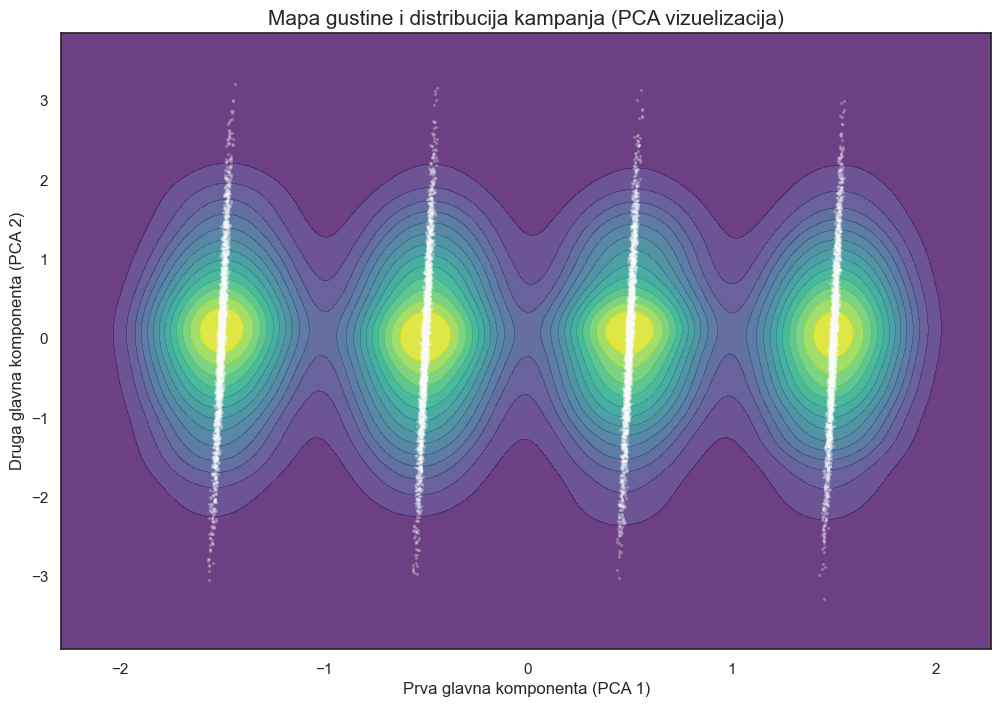

In [75]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
pca_transformed = pca.fit_transform(features_scaled)

sns.set(style="white")
plt.figure(figsize=(12, 8))

sns.kdeplot( x=pca_transformed[:, 0], y=pca_transformed[:, 1],fill=True,thresh=0, levels=15,cmap="viridis", alpha=0.8)

plt.scatter(pca_transformed[:, 0], pca_transformed[:, 1], s=2, facecolor='white', alpha=0.2)

plt.title('Mapa gustine i distribucija kampanja (PCA vizuelizacija)', fontsize=15)
plt.xlabel('Prva glavna komponenta (PCA 1)')
plt.ylabel('Druga glavna komponenta (PCA 2)')

plt.show()

Dok je inicijalni prikaz podataka pre klasterizacije podsećao na jednu amorfnu masu sa jednim centrom gravitacije, vizuelizacija nakon primene algoritama (poput K-Means) transformiše taj "oblak" u jasno definisanu strukturu sa četiri centra visoke gustine.

Na priloženom KDE grafikonu nakon klasterizacije uočavaju se sledeće ključne promene:

Formiranje četiri "vrha" (Centroida): Umesto jednog žutog jezgra, sada vidimo četiri izolovana svetla područja. Svako od ovih polja predstavlja centar jednog od četiri klastera, gde je koncentracija kampanja najveća.

Jasne linije razgraničenja: Algoritam je uspešno identifikovao matematičke granice unutar podataka, što se vidi po "udubljenjima" (tamnijim zonama) između žutih vrhova. Ovo pokazuje da su kampanje unutar jednog klastera međusobno sličnije nego kampanje iz susednih grupa.

Strukturna simetrija: Klasteri se protežu duž vertikalnih osa na mapi, što sugeriše da je segmentacija najviše uticala na varijansu koju pokriva druga glavna komponenta (PCA 2).

Potvrda iz metrika: Ovakva vizuelna separacija direktno podržava visoku vrednost Calinski-Harabasz indeksa (1548.22), koji meri upravo to koliko su klasteri dobro razmaknuti i zbijeni oko svojih centara.